In [21]:
!pip install yfinance tensorflow scikit-learn pandas numpy matplotlib --quiet

In [22]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, LayerNormalization, MultiHeadAttention
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

In [25]:
def flatten_col(series):

    arr = np.array(series)
    # If 2D with second dim 1, squeeze
    if arr.ndim > 1:
        if arr.shape[1] == 1:
            arr = arr[:, 0]
        else:
            # try to take first scalar from each row/element
            try:
                arr = np.array([np.array(x).ravel()[0] for x in arr])
            except Exception:
                arr = arr.reshape(arr.shape[0], -1)[:, 0]

    # If object dtype, try extracting scalars elementwise
    if arr.dtype == object:
        def extract_scalar(x):
            try:
                xa = np.array(x)
                if xa.size == 1:
                    return float(xa.item())
                else:
                    return float(xa.ravel()[0])
            except Exception:
                try:
                    return float(x)
                except Exception:
                    return np.nan
        arr = np.array([extract_scalar(x) for x in arr], dtype=float)

    return pd.Series(arr, index=series.index, name=series.name).astype(float)


In [26]:
def sma(series, window):
    s = pd.Series(series).astype(float)
    return s.rolling(window).mean()

def ema(series, span):
    s = pd.Series(series).astype(float)
    return s.ewm(span=span, adjust=False).mean()

def rsi(series, period=14):
    s = pd.Series(series).astype(float)
    delta = s.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

def macd(series, fast=12, slow=26, signal=9):
    s = pd.Series(series).astype(float)
    ema_fast = s.ewm(span=fast, adjust=False).mean()
    ema_slow = s.ewm(span=slow, adjust=False).mean()
    line = ema_fast - ema_slow
    signal_line = line.ewm(span=signal, adjust=False).mean()
    hist = line - signal_line
    return line, signal_line, hist


In [27]:
def debug_raw(raw):
    print("raw.shape:", getattr(raw, "shape", None))
    print("raw.columns:", raw.columns.tolist())
    if raw.shape[1] <= 10:
        # show first few elements types for Close if available
        if ("Close" in raw.columns) or (("Close" in [c if isinstance(c, str) else c[0] for c in raw.columns])):
            try:
                arr = np.array(raw.iloc[:, 0])
                print("first col np.array.shape:", arr.shape, "dtype:", arr.dtype)
                print("first 6 elem types:", [type(x) for x in raw.iloc[:, 0].head(6).tolist()])
            except Exception:
                pass


In [28]:
def add_indicators(df):
    """Robustly flatten and compute indicators (MA20, MA50, EMA20, RSI14, MACD, RET)."""
    df = df.copy()

    # If yfinance returned MultiIndex columns like ('Close','AAPL'), reduce to top-level name
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    debug_raw(df)  # helpful diagnostic

    # Flatten OHLCV columns to 1-D series
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        if col in df.columns:
            try:
                df[col] = flatten_col(df[col])
            except Exception as e:
                raise ValueError(f"Could not flatten column {col}: {e}")

    # Now compute indicators (pandas ops keep 1-D)
    df["MA20"] = sma(df["Close"], 20)
    df["MA50"] = sma(df["Close"], 50)
    df["EMA20"] = ema(df["Close"], 20)
    df["RSI14"] = rsi(df["Close"], 14)
    macd_line, macd_signal, macd_hist = macd(df["Close"])
    df["MACD"] = macd_line
    df["MACD_SIGNAL"] = macd_signal
    df["MACD_HIST"] = macd_hist
    df["RET"] = df["Close"].pct_change()

    df = df.dropna().copy()
    return df



In [29]:
ticker = "AAPL"     # <-- change (e.g., "TSLA", "MSFT", "INFY.NS")
start  = "2015-01-01"
end    = "2025-01-01"

# use auto_adjust=True to avoid a FutureWarning and get adjusted close/price behavior
raw = yf.download(ticker, start=start, end=end, auto_adjust=True)

# Flatten MultiIndex if present (defensive)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [c[0] for c in raw.columns]

# Compute indicators (this will print a little debug info once)
df  = add_indicators(raw)

feature_cols = ["Close","MA20","MA50","EMA20","RSI14","MACD","MACD_SIGNAL","MACD_HIST","RET"]
target_col   = "Close"
time_steps   = 60

[*********************100%***********************]  1 of 1 completed

raw.shape: (2516, 5)
raw.columns: ['Close', 'High', 'Low', 'Open', 'Volume']
first col np.array.shape: (2516,) dtype: float64
first 6 elem types: [<class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>]


In [30]:
def make_sequences(df, feature_cols, target_col="Close", time_steps=60, scalers=None):
    # Ensure feature columns exist
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing feature columns: {missing}")

    X, y = [], []
    data = df[feature_cols].values.astype(np.float32)
    target = df[[target_col]].values.astype(np.float32)

    if scalers is None:
        x_scaler = MinMaxScaler(); y_scaler = MinMaxScaler()
        data_scaled   = x_scaler.fit_transform(data)
        target_scaled = y_scaler.fit_transform(target)
    else:
        x_scaler, y_scaler = scalers
        data_scaled   = x_scaler.transform(data)
        target_scaled = y_scaler.transform(target)

    for i in range(time_steps, len(data_scaled)):
        X.append(data_scaled[i-time_steps:i])
        y.append(target_scaled[i])
    return np.array(X), np.array(y), (x_scaler, y_scaler)


In [31]:
X, y, (x_scaler, y_scaler) = make_sequences(df, feature_cols, target_col, time_steps)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [32]:
def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


In [33]:
def build_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


In [34]:
def build_transformer(input_shape, num_heads=4, key_dim=32, ff_dim=64, dropout=0.1):
    inp = Input(shape=input_shape)                      # (time, features)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(inp, inp)
    x = Dropout(dropout)(x); x = x + inp; x = LayerNormalization()(x)
    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(input_shape[-1])(ff)
    x = LayerNormalization()(x + ff)
    x = tf.reduce_mean(x, axis=1)                      # global average over time
    x = Dense(64, activation="relu")(x)
    out = Dense(1)(x)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="mse")
    return model


In [35]:
model_name = "LSTM"
input_shape = (X_train.shape[1], X_train.shape[2])
if model_name == "LSTM":
    model = build_lstm(input_shape)
elif model_name == "GRU":
    model = build_gru(input_shape)
else:
    model = build_transformer(input_shape)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,081 (211.25 KB)

 Trainable params: 54,081 (211.25 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20, batch_size=32, callbacks=[es], verbose=1
)


Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 0.0172 - val_loss: 0.0055
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 0.0012 - val_loss: 0.0030
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0011 - val_loss: 0.0045
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0010 - val_loss: 0.0089
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 7.4974e-04 - val_loss: 0.0061
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 8.6175e-04 - val_loss: 0.0041


In [37]:
y_pred_scaled = model.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


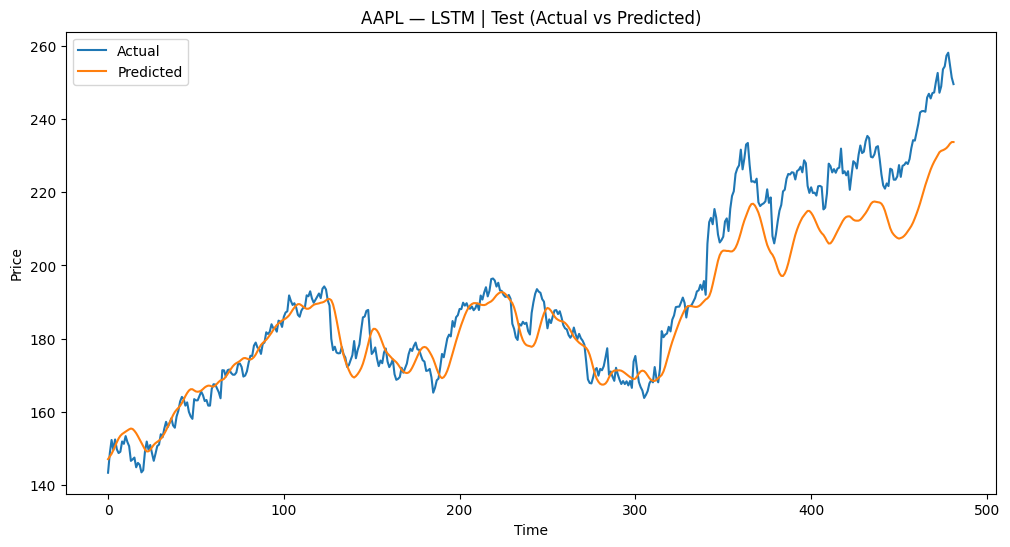

In [38]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title(f"{ticker} — {model_name} | Test (Actual vs Predicted)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(); plt.show()

In [39]:
def iterative_forecast(model, last_window, steps, x_scaler, y_scaler, feature_cols, df_tail_template):
    preds = []
    window = last_window.copy()
    temp_df = df_tail_template.copy()

    for i in range(steps):
        x = window[np.newaxis, ...]
        y_scaled = model.predict(x, verbose=0)
        y_pred = float(y_scaler.inverse_transform(y_scaled.reshape(-1,1))[0,0])
        preds.append(y_pred)

        # update last row and recompute indicators
        # create a new row with next business-day index
        last_idx = temp_df.index[-1]
        # choose next business day for index
        next_idx = last_idx + pd.Timedelta(days=1)
        new_row = temp_df.iloc[-1].copy()
        new_row["Close"] = y_pred
        new_row["Open"]  = y_pred
        new_row["High"]  = max(y_pred, float(temp_df.iloc[-1]["High"]))
        new_row["Low"]   = min(y_pred, float(temp_df.iloc[-1]["Low"]))
        new_row["Volume"] = float(temp_df.iloc[-1]["Volume"])
        temp_df = pd.concat([temp_df, pd.DataFrame([new_row], index=[next_idx])])

        # recompute indicators on the extended temp_df
        temp_ind = add_indicators(temp_df)
        # Build window from feature_cols last time_steps rows
        features_mat = temp_ind[feature_cols].values.astype(np.float32)
        window = x_scaler.transform(features_mat)[-window.shape[0]:]

    return preds


In [40]:
last_window = X[-1]  # scaled
df_tail_template = df.tail(max(60, time_steps)).copy()
future_days = 7
preds = iterative_forecast(model, last_window, future_days, x_scaler, y_scaler, feature_cols, df_tail_template)
future_idx = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=future_days, freq="B")
forecast_df = pd.DataFrame({"Predicted_Close": preds}, index=future_idx)
print(forecast_df)

raw.shape: (61, 13)
raw.columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50', 'EMA20', 'RSI14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RET']
raw.shape: (62, 13)
raw.columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50', 'EMA20', 'RSI14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RET']
raw.shape: (63, 13)
raw.columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50', 'EMA20', 'RSI14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RET']
raw.shape: (64, 13)
raw.columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50', 'EMA20', 'RSI14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RET']
raw.shape: (65, 13)
raw.columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50', 'EMA20', 'RSI14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RET']
raw.shape: (66, 13)
raw.columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50', 'EMA20', 'RSI14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST', 'RET']
raw.shape: (67, 13)
raw.columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA20'